In [1]:
from Data_query.trino_config import *
import numpy as np
from visualisation import *
import pytz

In [4]:
stop_trino()

Trino service stopping triggered.


In [2]:
big_workers = 3
workers = 0
num_workers = max(workers, big_workers)
ensure_trino_running(worker_desired_count = workers, big_worker_desired_count=big_workers)
sleep(40)

Trino service is not running. Starting the service...
Trino service triggered.
Service trino-service is now stable.


In [9]:
iceberg_sql(f""" select * from meta_up23c 
            limit 2""")

,site_id,state,postcode,longitude,latitude,dnsp_name,dc_capacity_kw,ac_capacity_kw,export_limit_kw,monitoring_start,...,voltage_class,m_id,avg_pf,std_pf,pf_99,pf_01,n_long,n_lat,distance_km,s_99
0,500302086,QLD,4817,146.75,-19.305,Ergon,5.0,4.6,None,2022-09-21,...,neutral-absorb,M29,0.885582,0.019276,0.957238,0.862803,146.74,-19.30,1.241018,None
1,1263606985,SA,5095,138.60,-34.830,SAPN,5.9,5.4,None,2018-09-15,...,neutral-absorb,M13,0.990550,0.006146,0.995681,0.962986,138.60,-34.82,1.110000,None


In [4]:
iceberg_sql(f""" select distinct site_id, ac_capacity_kw, state, min_time, max_time from meta_up23c 
            where is_pv=True and flex_export_detected=False and pf_01 > .98 and min_time < timestamp '2024-01-02'
            limit 2""")

,site_id,ac_capacity_kw,state,min_time,max_time
0,261276652,4.2,QLD,2024-01-01,2025-06-22 00:05:00
1,2111538233,5.0,SA,2024-01-01,2025-12-31 23:55:00


In [3]:
# big_workers = 1
# workers = 0
# num_workers = max(workers, big_workers)
# ensure_trino_running(worker_desired_count = workers, big_worker_desired_count=big_workers)
sleep(60)
def run_func(args):
    year, month, split_cons = args
    # time_filter = f"year = {year} and month = {month}"
    time_filter = f"year = {year}"
    meta_filters = f"is_pv=True and {split_cons} and flex_export_detected=False and pf_01 >= .98"
    # meta_filters = f"is_pv=True and {split_cons} and flex_export_detected=False and site_id in (1669657679,1947677239)"
    df = iceberg_sql(f"""
                    with data as 
                        (select 
                            site_id, t_stamp,  sum(power*circuit_polarity/ac_capacity_kw)/1000 as P_kw_norm
                        from ts join 
                            (select site_id, circuit_id, circuit_polarity, ac_capacity_kw  from meta_up23c where {meta_filters})
                            as m on ts.circuit_id = m.circuit_id
                        where {time_filter} and is_pv=True and voltage >= 200 and voltage <= 300 and {split_cons}
                        group by site_id, t_stamp
                            ),
                    bom10min as (
                        select 
                            distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                        from bom_nci.solar as b
                            join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) as m 
                            on b.latitude = m.n_lat and b.longitude = m.n_long
                        where {time_filter} and {split_cons} 
                    ),
                    bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                    from bom10min) 
                    union all
                    (select date_add('minute', 5, time) as time_5min, latitude, longitude, GHI, cloud_type
                    FROM bom10min ORDER BY time_5min)),
                    daily_cloud AS (
                        SELECT
                            latitude, longitude,
                            date_trunc('day', time + interval '10' hour)   AS day,
                            date_trunc('month', time + interval '10' hour) AS month,
                            sum(cloud_type) AS cloud_sum, 
                            max(GHI) AS max_GHI
                        FROM bom10min
                        GROUP BY
                            1, 2, 3, 4
                    ),
                    clear_sky AS (
                            SELECT day, latitude, longitude
                            FROM (SELECT day, latitude, longitude, cloud_sum, max_GHI, row_number() OVER (
                                                                    PARTITION BY month, latitude, longitude
                                                                    ORDER BY cloud_sum ASC
                                                                    ) AS rn
                                FROM daily_cloud 
                            )
                            WHERE rn < 4 and cloud_sum < 60 and max_GHI > 200
                        ),
                    daily_site_days AS (
                            SELECT 
                                n_lat,
                                n_long,
                                date_trunc('day', t_stamp + interval '10' hour) AS day
                            FROM data d join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            on d.site_id = m.site_id
                            group by n_lat, n_long, date_trunc('day', t_stamp + interval '10' hour) 
                        ),
                    nearest_clear_sky_day AS (
                        SELECT
                            dy.n_lat,
                            dy.n_long,
                            dy.day AS actual_day,
                            c.day AS clear_sky_day,
                            row_number() OVER (
                                PARTITION BY dy.n_lat, dy.n_long, dy.day
                                ORDER BY abs(date_diff('day', dy.day, c.day))
                            ) AS rn
                        FROM daily_site_days dy JOIN clear_sky c
                            ON dy.n_lat = c.latitude AND dy.n_long = c.longitude
                    ),
                    nearest_clear_sky AS (
                            SELECT
                                n_lat,
                                n_long,
                                actual_day,
                                clear_sky_day
                            FROM nearest_clear_sky_day
                            WHERE rn = 1
                        ),
                    nearest_cs_days AS (
                        SELECT
                            DISTINCT site_id, clear_sky_day AS cs_day 
                        FROM nearest_clear_sky n JOIN (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            ON n.n_lat = m.n_lat AND n.n_long = m.n_long
                    ),
                    base AS (
                            SELECT
                                d.*,
                                lag(t_stamp) OVER (
                                    PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                    ORDER BY t_stamp
                                ) AS prev_ts
                            FROM data d
                    ),
                    gaps AS (
                        SELECT *,
                            CASE
                                WHEN prev_ts IS NULL THEN 0
                                WHEN t_stamp - prev_ts > interval '30' minute THEN 1
                                ELSE 0
                            END AS gap_start
                        FROM base
                    ),
                    segments AS (
                        SELECT *,
                            sum(gap_start) OVER (
                                PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                ORDER BY t_stamp
                                ROWS UNBOUNDED PRECEDING
                            ) AS segment_id
                        FROM gaps
                    ),
                    nearest_cs_profiles AS (
                        SELECT
                            s.site_id,
                            date_trunc('day', s.t_stamp + interval '10' hour) AS cs_day,
                            (s.t_stamp + interval '10' hour) - date_trunc('day', s.t_stamp + interval '10' hour) AS cs_tod,
                            approx_percentile(P_kw_norm, 0.6) OVER (
                                    PARTITION BY s.site_id, date_trunc('day', s.t_stamp + interval '10' hour), segment_id
                                        ORDER BY t_stamp
                                        ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
                                    ) AS P_kw_norm_cs,
                            approx_percentile(GHI, 0.6) OVER (
                            PARTITION BY s.site_id, date_trunc('day', s.t_stamp + interval '10' hour), segment_id
                                ORDER BY t_stamp
                                ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
                            ) AS GHI_cs,
                            cloud_type as cloud_type_cs
                        FROM segments s join nearest_cs_days n on s.site_id = n.site_id and 
                            date_trunc('day', s.t_stamp + interval '10' hour) = n.cs_day
                            join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m on s.site_id = m.site_id
                            join bom5min b on m.n_lat = b.latitude and m.n_long = b.longitude and b.time_5min = s.t_stamp
                    ),
                    strcutured_data AS (
                    SELECT
                        d.site_id,
                        d.t_stamp,
                        date_trunc('day', d.t_stamp + interval '10' hour) AS actual_day,
                        (d.t_stamp + interval '10' hour) - date_trunc('day', d.t_stamp + interval '10' hour) AS actual_tod,
                        d.P_kw_norm, 
                        GHI,
                        cloud_type,
                        ncs.cs_day,
                        ncs.cs_tod,
                        ncs.P_kw_norm_cs,
                        ncs.GHI_cs, 
                        ncs.cloud_type_cs
                    FROM data d 
                        join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            ON d.site_id = m.site_id 
                        join nearest_cs_profiles ncs 
                            on d.site_id = ncs.site_id and ncs.cs_tod = (d.t_stamp + interval '10' hour) - date_trunc('day', d.t_stamp + interval '10' hour)
                        join nearest_clear_sky n on 
                            n.n_lat = m.n_lat AND n.n_long = m.n_long and n.actual_day = date_trunc('day', d.t_stamp + interval '10' hour)
                            and n.clear_sky_day = ncs.cs_day
                        join bom5min b on m.n_lat = b.latitude and m.n_long = b.longitude and b.time_5min = d.t_stamp
                        order by d.site_id, d.t_stamp),
                    train AS (
                        SELECT
                            site_id,
                            t_stamp,
                            CAST(
                                date_trunc('minute', t_stamp + interval '10' hour)
                                - interval '1' minute * (minute(t_stamp + interval '10' hour) % 30)
                                AS TIME) AS tod_bin,
                            GHI AS x,
                            P_kw_norm/ NULLIF(P_kw_norm_cs, 0.0) AS y
                        FROM strcutured_data
                        WHERE P_kw_norm_cs > 0.05 AND GHI > 50 and P_kw_norm > 0.05
                    ),
                    model AS (
                        SELECT
                            site_id,
                            tod_bin,
                            regr_intercept(y, x) AS a,
                            regr_slope(y, x)     AS b,
                            count(*)             AS n
                        FROM train
                        GROUP BY site_id, tod_bin
                    ),
                    validation AS (
                        select 
                            s.site_id, 
                            t_stamp, 
                            GHI, 
                            cloud_type,
                            P_kw_norm, 
                            P_kw_norm_cs * (a + b * GHI) AS P_kw_norm_est
                        from strcutured_data s join model m on s.site_id = m.site_id and 
                            CAST(
                                date_trunc('minute', s.t_stamp + interval '10' hour)
                                - interval '1' minute * (minute(s.t_stamp + interval '10' hour) % 30)
                                AS TIME) = m.tod_bin
                    )
                    SELECT
                        v.site_id,
                        count(*) AS n,
                        pow(corr(P_kw_norm, P_kw_norm_est), 2) AS r2,
                        avg( abs(P_kw_norm - P_kw_norm_est) / NULLIF(abs(P_kw_norm), 0.0) )
                        FILTER (WHERE abs(P_kw_norm) > 0.2) * 100 AS mape,
                        sqrt(avg(pow(P_kw_norm - P_kw_norm_est, 2)))*ac_capacity_kw AS rmse,
                        avg(abs(P_kw_norm - P_kw_norm_est))*ac_capacity_kw AS mae,
                        avg(P_kw_norm - P_kw_norm_est)*ac_capacity_kw AS bias
                    FROM validation v
                        join (select distinct site_id, ac_capacity_kw from meta_up23c where {meta_filters}) as meta on v.site_id = meta.site_id
                    GROUP BY v.site_id, ac_capacity_kw
                    ORDER BY r2 DESC



                    
                
    """)
    # sleep(20)
    print(f"Completed {time_filter}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df
tasks = [(year, month, split_cons) for year in (2024, ) for month in range(1, 2) 
         for split_cons in [f'system.bucket(postcode, 16) = {i}' for i in range(0, 16)]]
        #   for split_cons in ['system.bucket(postcode, 16) > -1'] ]
            
try:         
    res = trino_parallel_batch(run_func, tasks, num_workers=num_workers, batch_size=num_workers)
except Exception as e:
    print(f"Error during data retrieval: {e}")
finally:
    stop_trino()
    pass

Completed year = 2024, bucket = 0
Completed year = 2024, bucket = 1
Completed year = 2024, bucket = 2
Completed year = 2024, bucket = 3
Completed year = 2024, bucket = 5
Completed year = 2024, bucket = 4
Completed year = 2024, bucket = 6
Completed year = 2024, bucket = 7
Completed year = 2024, bucket = 8
Completed year = 2024, bucket = 10
Completed year = 2024, bucket = 9
Completed year = 2024, bucket = 11
Completed year = 2024, bucket = 12
Completed year = 2024, bucket = 13
Completed year = 2024, bucket = 14
Sleeping for 30 seconds to reduce load on Trino...
Completed year = 2024, bucket = 15
Combining all batch results.
Trino service stopping triggered.


In [5]:
res['site_id'].nunique()

6201

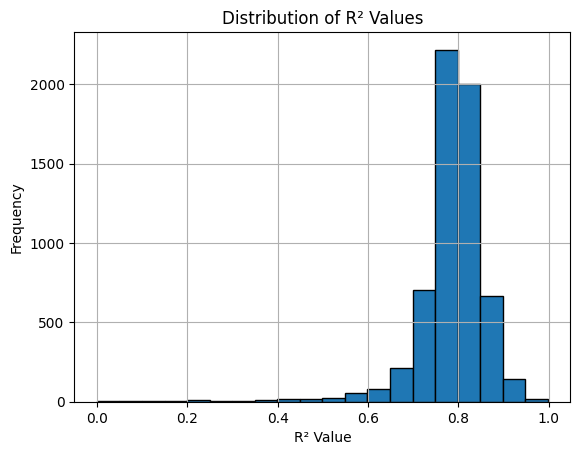

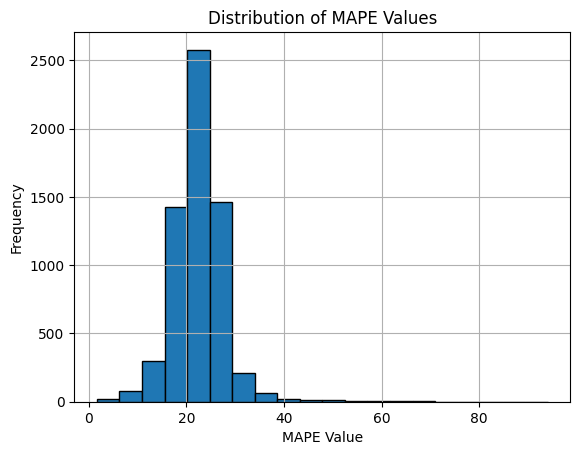

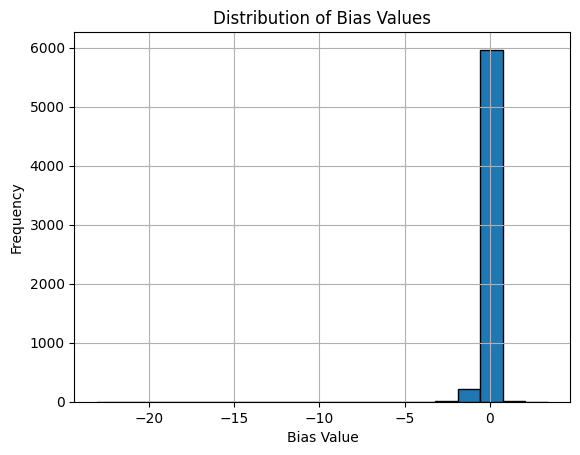

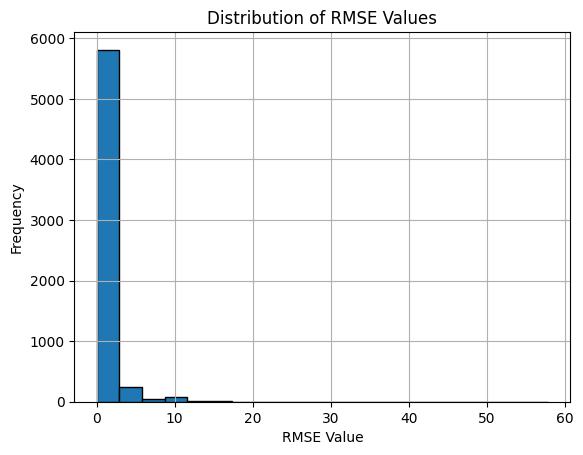

In [6]:
res.hist(column='r2', bins=20, edgecolor='k'), 
plt.xlabel('R² Value'), plt.ylabel('Frequency'), plt.title('Distribution of R² Values')
res.hist(column='mape', bins=20, edgecolor='k')
plt.xlabel('MAPE Value'), plt.ylabel('Frequency'), plt.title('Distribution of MAPE Values')
res.hist(column='bias', bins=20, edgecolor='k')
plt.xlabel('Bias Value'), plt.ylabel('Frequency'), plt.title('Distribution of Bias Values')
res.hist(column='rmse', bins=20, edgecolor='k')
plt.xlabel('RMSE Value'), plt.ylabel('Frequency'), plt.title('Distribution of RMSE Values')
plt.show()

In [32]:
res['rmse'].describe()

count    4572.000000
mean        0.899600
std         4.470792
min         0.004684
25%         0.314311
50%         0.459400
75%         0.711809
max       223.743569
Name: rmse, dtype: float64

In [37]:
res.query(f'rmse > 15')['site_id']

1186     209875442
1780     272450974
1781     539826332
2444     206812690
2450      45773670
2452     109161488
3034     988931914
3043     686536824
3512    1372731376
4569    1401419192
4571      14711880
4572     818680985
Name: site_id, dtype: int64

In [24]:
sleep(120)

In [38]:
# big_workers = 1
# workers = 0
# num_workers = max(workers, big_workers)
ensure_trino_running(worker_desired_count = workers, big_worker_desired_count=big_workers)
sleep(110)
def run_func(args):
    year, month, split_cons = args
    time_filter = f"year = {year} and month = {month}"
    # time_filter = f"year = {year}"
    # time_filter = f"year = {year} and month in (1, 2, 3)"
    # meta_filters = f"is_pv=True and {split_cons} and flex_export_detected=False and pf_01 >= .98"
    meta_filters = f"is_pv=True and {split_cons} and flex_export_detected=False and site_id in (104796697,315470904, 338973142, 1751627135, 136487847, 1736253011)"
    meta_filters = f"is_pv=True and {split_cons} and flex_export_detected=False and site_id in ({','.join(map(str, res.query(f'rmse > 15')['site_id'].tolist()))})"
    df = iceberg_sql(f"""
                    with data as 
                        (select 
                            site_id, t_stamp,  sum(power*circuit_polarity/ac_capacity_kw)/1000 as P_kw_norm
                        from ts join 
                            (select site_id, circuit_id, circuit_polarity, ac_capacity_kw  from meta_up23c where {meta_filters})
                            as m on ts.circuit_id = m.circuit_id
                        where {time_filter} and is_pv=True and voltage >= 200 and voltage <= 300 and {split_cons}
                        group by site_id, t_stamp
                            ),
                    bom10min as (
                        select 
                            distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                        from bom_nci.solar as b
                            join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) as m 
                            on b.latitude = m.n_lat and b.longitude = m.n_long
                        where {time_filter} and {split_cons} 
                    ),
                    bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                    from bom10min) 
                    union all
                    (select date_add('minute', 5, time) as time_5min, latitude, longitude, GHI, cloud_type
                    FROM bom10min ORDER BY time_5min)),
                    daily_cloud AS (
                        SELECT
                            latitude, longitude,
                            date_trunc('day', time + interval '10' hour)   AS day,
                            date_trunc('month', time + interval '10' hour) AS month,
                            sum(cloud_type) AS cloud_sum, 
                            max(GHI) AS max_GHI
                        FROM bom10min
                        GROUP BY
                            1, 2, 3, 4
                    ),
                    clear_sky AS (
                            SELECT day, latitude, longitude
                            FROM (SELECT day, latitude, longitude, cloud_sum, max_GHI, row_number() OVER (
                                                                    PARTITION BY month, latitude, longitude
                                                                    ORDER BY cloud_sum ASC
                                                                    ) AS rn
                                FROM daily_cloud 
                            )
                            WHERE rn < 4 and cloud_sum < 60 and max_GHI > 200
                        ),
                    daily_site_days AS (
                            SELECT 
                                n_lat,
                                n_long,
                                date_trunc('day', t_stamp + interval '10' hour) AS day
                            FROM data d join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            on d.site_id = m.site_id
                            group by n_lat, n_long, date_trunc('day', t_stamp + interval '10' hour) 
                        ),
                    nearest_clear_sky_day AS (
                        SELECT
                            dy.n_lat,
                            dy.n_long,
                            dy.day AS actual_day,
                            c.day AS clear_sky_day,
                            row_number() OVER (
                                PARTITION BY dy.n_lat, dy.n_long, dy.day
                                ORDER BY abs(date_diff('day', dy.day, c.day))
                            ) AS rn
                        FROM daily_site_days dy JOIN clear_sky c
                            ON dy.n_lat = c.latitude AND dy.n_long = c.longitude
                    ),
                    nearest_clear_sky AS (
                            SELECT
                                n_lat,
                                n_long,
                                actual_day,
                                clear_sky_day
                            FROM nearest_clear_sky_day
                            WHERE rn = 1
                        ),
                    nearest_cs_days AS (
                        SELECT
                            DISTINCT site_id, clear_sky_day AS cs_day 
                        FROM nearest_clear_sky n JOIN (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            ON n.n_lat = m.n_lat AND n.n_long = m.n_long
                    ),
                    base AS (
                            SELECT
                                d.*,
                                lag(t_stamp) OVER (
                                    PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                    ORDER BY t_stamp
                                ) AS prev_ts
                            FROM data d
                    ),
                    gaps AS (
                        SELECT *,
                            CASE
                                WHEN prev_ts IS NULL THEN 0
                                WHEN t_stamp - prev_ts > interval '30' minute THEN 1
                                ELSE 0
                            END AS gap_start
                        FROM base
                    ),
                    segments AS (
                        SELECT *,
                            sum(gap_start) OVER (
                                PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                ORDER BY t_stamp
                                ROWS UNBOUNDED PRECEDING
                            ) AS segment_id
                        FROM gaps
                    ),
                    nearest_cs_profiles AS (
                        SELECT
                            s.site_id,
                            date_trunc('day', s.t_stamp + interval '10' hour) AS cs_day,
                            (s.t_stamp + interval '10' hour) - date_trunc('day', s.t_stamp + interval '10' hour) AS cs_tod,
                            approx_percentile(P_kw_norm, 0.6) OVER (
                                    PARTITION BY s.site_id, date_trunc('day', s.t_stamp + interval '10' hour), segment_id
                                        ORDER BY t_stamp
                                        ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
                                    ) AS P_kw_norm_cs,
                            approx_percentile(GHI, 0.6) OVER (
                            PARTITION BY s.site_id, date_trunc('day', s.t_stamp + interval '10' hour), segment_id
                                ORDER BY t_stamp
                                ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
                            ) AS GHI_cs,
                            cloud_type as cloud_type_cs
                        FROM segments s join nearest_cs_days n on s.site_id = n.site_id and 
                            date_trunc('day', s.t_stamp + interval '10' hour) = n.cs_day
                            join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m on s.site_id = m.site_id
                            join bom5min b on m.n_lat = b.latitude and m.n_long = b.longitude and b.time_5min = s.t_stamp
                    ),
                    strcutured_data AS (
                    SELECT
                        d.site_id,
                        d.t_stamp,
                        date_trunc('day', d.t_stamp + interval '10' hour) AS actual_day,
                        (d.t_stamp + interval '10' hour) - date_trunc('day', d.t_stamp + interval '10' hour) AS actual_tod,
                        d.P_kw_norm, 
                        GHI,
                        cloud_type,
                        ncs.cs_day,
                        ncs.cs_tod,
                        ncs.P_kw_norm_cs,
                        ncs.GHI_cs, 
                        ncs.cloud_type_cs
                    FROM data d 
                        join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            ON d.site_id = m.site_id 
                        join nearest_cs_profiles ncs 
                            on d.site_id = ncs.site_id and ncs.cs_tod = (d.t_stamp + interval '10' hour) - date_trunc('day', d.t_stamp + interval '10' hour)
                        join nearest_clear_sky n on 
                            n.n_lat = m.n_lat AND n.n_long = m.n_long and n.actual_day = date_trunc('day', d.t_stamp + interval '10' hour)
                            and n.clear_sky_day = ncs.cs_day
                        join bom5min b on m.n_lat = b.latitude and m.n_long = b.longitude and b.time_5min = d.t_stamp
                        order by d.site_id, d.t_stamp),
                    train AS (
                        SELECT
                            site_id,
                            t_stamp,
                            date_trunc('hour', t_stamp + interval '10' hour)
                            + (minute(t_stamp + interval '10' hour) / 30) * interval '30' minute AS tod_bin,
                            GHI AS x,
                            P_kw_norm/ NULLIF(P_kw_norm_cs, 0.0) AS y
                        FROM strcutured_data
                        WHERE P_kw_norm_cs > 0.05 AND GHI > 50
                    ),
                    model AS (
                        SELECT
                            site_id,
                            tod_bin,
                            regr_intercept(y, x) AS a,
                            regr_slope(y, x)     AS b,
                            count(*)             AS n
                        FROM train
                        GROUP BY site_id, tod_bin
                    )
                    select 
                        s.site_id, 
                        t_stamp, 
                        GHI, 
                        cloud_type,
                        P_kw_norm * ac_capacity_kw AS P_kw, 
                        P_kw_norm_cs * (a + b * GHI) * ac_capacity_kw AS P_kw_est 
                    from strcutured_data s join model m on s.site_id = m.site_id and 
                        (date_trunc('hour', t_stamp + interval '10' hour)
                            + (minute(t_stamp + interval '10' hour) / 30) * interval '30' minute) = m.tod_bin
                        join (select distinct site_id, ac_capacity_kw from meta_up23c where {meta_filters}) as meta on s.site_id = meta.site_id
                    
                
    """)
    print(f"Completed {time_filter}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df
tasks = [(year, month, split_cons) for year in (2024, ) for month in range(1, 2) 
         for split_cons in [f'system.bucket(postcode, 16) = {i}' for i in range(0, 16)]]
        #   for split_cons in ['system.bucket(postcode, 16) > -1'] ]
            
try:         
    df = trino_parallel(run_func, tasks, num_workers=num_workers)
    df['t_stamp'] = pd.to_datetime(df['t_stamp']).dt.tz_localize('utc').dt.tz_convert(pytz.FixedOffset(10*60))
    df['GHI'] = df['GHI'].fillna(-1)
    # df['GHI_cs'] = df['GHI_cs'].fillna(-1)
    df['cloud_type'] = df['cloud_type'].fillna(-1)
    # df['cloud_type_cs'] = df['cloud_type_cs'].fillna(-1)
except Exception as e:
    print(f"Error during data retrieval: {e}")
finally:
    stop_trino()
    pass

Trino service is not running. Starting the service...
Trino service triggered.
Service trino-service is now stable.
Completed year = 2024 and month = 1, bucket = 0Completed year = 2024 and month = 1, bucket = 2

Completed year = 2024 and month = 1, bucket = 1
Completed year = 2024 and month = 1, bucket = 3
Completed year = 2024 and month = 1, bucket = 4
Completed year = 2024 and month = 1, bucket = 6
Completed year = 2024 and month = 1, bucket = 5
Completed year = 2024 and month = 1, bucket = 7
Completed year = 2024 and month = 1, bucket = 11
Completed year = 2024 and month = 1, bucket = 9
Completed year = 2024 and month = 1, bucket = 8
Completed year = 2024 and month = 1, bucket = 10
Completed year = 2024 and month = 1, bucket = 12
Completed year = 2024 and month = 1, bucket = 13
Completed year = 2024 and month = 1, bucket = 15
Completed year = 2024 and month = 1, bucket = 14
Combining results from all tasks.
Trino service stopping triggered.


In [39]:
df['site_id'].unique()

array([209875442, 539826332, 272450974, 109161488, 45773670, 206812690,
       1372731376, 988931914, 686536824, 1401419192, 14711880, 818680985],
      dtype=object)

In [25]:
df.merge(res[['site_id', 'r2', 'mape', 'rmse','n']], on='site_id', how='left').query(f'site_id=={1478393681}')

,site_id,t_stamp,GHI,cloud_type,P_kw,P_kw_est,r2,mape,rmse,n
1100446,1478393681,2024-02-01 10:10:00+10:00,676.37,6,0.843297,0.794798,0.147192,15.691369,2.144517,18748
1100447,1478393681,2024-02-01 17:05:00+10:00,343.44,0,0.363023,0.420849,0.147192,15.691369,2.144517,18748
1100448,1478393681,2024-02-01 17:20:00+10:00,261.14,0,0.084783,0.042624,0.147192,15.691369,2.144517,18748
1100449,1478393681,2024-02-02 07:40:00+10:00,427.26,0,1.114860,1.031961,0.147192,15.691369,2.144517,18748
1100450,1478393681,2024-02-02 08:00:00+10:00,411.35,6,0.696843,0.773338,0.147192,15.691369,2.144517,18748
...,...,...,...,...,...,...,...,...,...,...
1199655,1478393681,2024-03-30 12:25:00+10:00,283.99,5,0.985483,2.738626,0.147192,15.691369,2.144517,18748
1199656,1478393681,2024-03-30 16:50:00+10:00,218.30,0,0.709417,0.448239,0.147192,15.691369,2.144517,18748
1199657,1478393681,2024-03-31 11:05:00+10:00,312.74,5,1.139433,0.802537,0.147192,15.691369,2.144517,18748
1199658,1478393681,2024-03-31 11:45:00+10:00,585.27,5,2.188380,2.433182,0.147192,15.691369,2.144517,18748


In [40]:
df.merge(res[['site_id', 'r2', 'mape', 'rmse','n']], on='site_id', how='left').drop_duplicates(subset=['site_id']).sort_values('rmse', ascending=False)

,site_id,t_stamp,GHI,cloud_type,P_kw,P_kw_est,r2,mape,rmse,n
36475,14711880,2024-01-14 06:10:00+10:00,166.00,0,3.496787,2.705293,0.019264,8.238125,223.743569,4103
10229,109161488,2024-01-31 16:00:00+10:00,281.63,5,32.785860,33.566766,0.025599,10.663547,175.282391,4263
4356,539826332,2024-01-31 07:20:00+10:00,313.51,6,2.015020,2.457050,0.000360,22.886349,45.460601,1471
0,209875442,2024-02-01 07:20:00+10:00,164.32,5,0.397633,0.458076,0.000377,13.548429,24.280195,3959
38281,818680985,2024-01-22 14:55:00+10:00,869.11,0,5.461347,5.474258,0.015636,7.566490,23.303337,4010
21422,1372731376,2024-02-01 09:30:00+10:00,450.17,5,1.313003,0.832329,0.008601,10.267688,20.638990,3889
13632,45773670,2024-01-11 16:20:00+10:00,715.90,0,15.455440,15.498825,0.136438,4.555087,19.282064,2383
14293,206812690,2024-01-26 10:35:00+10:00,762.50,5,21.139663,20.924865,0.207429,5.169114,17.776812,4172
25517,988931914,2024-01-06 16:10:00+10:00,519.94,0,19.270800,19.400793,0.261720,8.013821,16.509826,4499
34451,1401419192,2024-01-30 15:30:00+10:00,694.45,0,7.267333,6.719850,0.056553,7.906531,15.763169,3851


In [26]:
id_counter=-1

In [41]:
t0, t1

(Timestamp('2024-12-23 06:00:00+1000', tz='pytz.FixedOffset(600)'),
 Timestamp('2025-01-01 09:55:00+1000', tz='pytz.FixedOffset(600)'))

In [41]:
# sample_site_id = 1582597870
sample_site_id = 14711880
# id_counter+=1
# sample_site_id = df.groupby('site_id').size().reset_index()
# sample_site_id = sample_site_id[sample_site_id[0] > 0]['site_id'].tolist()
# df0 = df.query(f"site_id=={sample_site_id[id_counter]}").reset_index(drop=True)
df0 = df.query(f"site_id=={sample_site_id}").reset_index(drop=True)
t0 = df0['t_stamp'].min()
t1 = df0['t_stamp'].max()
# t1 = t0 + pd.Timedelta(days=6)
if t0.time() == pd.Timestamp('00:00:00').time():
    start_time = t0.strftime('%Y-%m-%d %H:%M:%S%z')
else:
    start_time = (t0 + pd.Timedelta(days=1)).replace(hour=0, minute=0, second=0).strftime('%Y-%m-%d %H:%M:%S%z')
if t1.time() == pd.Timestamp('00:00:00').time():
    end_time = t1.strftime('%Y-%m-%d %H:%M:%S%z')
else:
    end_time = t1.replace(hour=0, minute=0, second=0).strftime('%Y-%m-%d %H:%M:%S%z')

num_ticks = 24*2+1
save_as = 'Figures/Test2.jpeg'
x_label = 'time'
y_labels = ['GHI', 'Cloud Type', 'Active Power (kW)', 'Active Power (kW)']
plt_config = {
    'GHI': [0, 0, '-', None, None],'cloud_type': [0, 1, '-', None, None],
    'P_kw': [1, 0, '-', None, None],'P_kw_est': [1, 0, '-', None, None],
}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, df0, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='site_id', time_attr='t_stamp', color_nights=color_nights,cmap='plasma',
          figsize=[16/2.54,1.3],  same_scale=1, fontsize=5, fontname='DejaVu Sans', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=200,  x_format= '%H:%M', 
           legend_loc=['upper left', 'upper right', 'center left','upper left'], x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', 
legend_i=0, title_i=0, only1title=0, onlyntime=0, show=False)
a.do()

saved as:  /home/hossein/CICCADA/Figures/Test2.jpeg


In [36]:
ensure_trino_running(worker_desired_count = workers, big_worker_desired_count=big_workers)
sleep(50)
def run_func(args):
    year, month, split_cons = args
    # meta_filters = f"is_pv=True and {split_cons} and flex_export_detected=False and pf_01 >= .98"
    meta_filters = f"is_pv=True and {split_cons} and flex_export_detected=False and site_id in (1669657679,1947677239)"
    df = iceberg_sql(f"""
                    with data as 
                        (select 
                            site_id, t_stamp,  sum(power*circuit_polarity/ac_capacity_kw)/1000 as P_kw_norm
                        from ts join 
                            (select site_id, circuit_id, circuit_polarity, ac_capacity_kw  from meta_up23c where {meta_filters})
                            as m on ts.circuit_id = m.circuit_id
                        where year = {year} and  month = {month}  and is_pv=True and voltage >= 200 and voltage <= 300 and {split_cons}
                        group by site_id, t_stamp
                            ),
                    bom10min as (
                        select 
                            distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                        from bom_nci.solar as b
                            join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) as m 
                            on b.latitude = m.n_lat and b.longitude = m.n_long
                        where year = {year} and  month = {month}  and {split_cons} 
                    ),
                    bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                    from bom10min) 
                    union all
                    (select date_add('minute', 5, time) as time_5min, latitude, longitude, GHI, cloud_type
                    FROM bom10min ORDER BY time_5min)),
                    daily_cloud AS (
                        SELECT
                            latitude, longitude,
                            date_trunc('day', time + interval '10' hour)   AS day,
                            date_trunc('month', time + interval '10' hour) AS month,
                            sum(cloud_type) AS cloud_sum, 
                            max(GHI) AS max_GHI
                        FROM bom10min
                        GROUP BY
                            1, 2, 3, 4
                    ),
                    clear_sky AS (
                            SELECT day, latitude, longitude
                            FROM (SELECT day, latitude, longitude, cloud_sum, max_GHI, row_number() OVER (
                                                                    PARTITION BY month, latitude, longitude
                                                                    ORDER BY cloud_sum ASC
                                                                    ) AS rn
                                FROM daily_cloud 
                            )
                            WHERE rn < 4 and cloud_sum < 60 and max_GHI > 200
                        ),
                    daily_site_days AS (
                            SELECT 
                                n_lat,
                                n_long,
                                date_trunc('day', t_stamp + interval '10' hour) AS day
                            FROM data d join (select site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            on d.site_id = m.site_id
                            group by n_lat, n_long, date_trunc('day', t_stamp + interval '10' hour) 
                        ),
                    nearest_clear_sky_day AS (
                        SELECT
                            dy.n_lat,
                            dy.n_long,
                            dy.day AS actual_day,
                            c.day AS clear_sky_day,
                            row_number() OVER (
                                PARTITION BY dy.n_lat, dy.n_long, dy.day
                                ORDER BY abs(date_diff('day', dy.day, c.day))
                            ) AS rn
                        FROM daily_site_days dy JOIN clear_sky c
                            ON dy.n_lat = c.latitude AND dy.n_long = c.longitude
                    ),
                    nearest_clear_sky AS (
                            SELECT
                                n_lat,
                                n_long,
                                actual_day,
                                clear_sky_day
                            FROM nearest_clear_sky_day
                            WHERE rn = 1
                        ),
                    nearest_cs_days AS (
                        SELECT
                            DISTINCT site_id, clear_sky_day AS cs_day 
                        FROM nearest_clear_sky n JOIN (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            ON n.n_lat = m.n_lat AND n.n_long = m.n_long
                    ),
                    base AS (
                            SELECT
                                d.*,
                                lag(t_stamp) OVER (
                                    PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                    ORDER BY t_stamp
                                ) AS prev_ts
                            FROM data d
                    ),
                    gaps AS (
                        SELECT *,
                            CASE
                                WHEN prev_ts IS NULL THEN 0
                                WHEN t_stamp - prev_ts > interval '30' minute THEN 1
                                ELSE 0
                            END AS gap_start
                        FROM base
                    ),
                    segments AS (
                        SELECT *,
                            sum(gap_start) OVER (
                                PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                ORDER BY t_stamp
                                ROWS UNBOUNDED PRECEDING
                            ) AS segment_id
                        FROM gaps
                    ),
                    nearest_cs_profiles AS (
                        SELECT
                            s.site_id,
                            date_trunc('day', s.t_stamp + interval '10' hour) AS cs_day,
                            (s.t_stamp + interval '10' hour) - date_trunc('day', s.t_stamp + interval '10' hour) AS cs_tod,
                            approx_percentile(P_kw_norm, 0.6) OVER (
                                    PARTITION BY s.site_id, date_trunc('day', s.t_stamp + interval '10' hour), segment_id
                                        ORDER BY t_stamp
                                        ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
                                    ) AS P_kw_norm_cs,
                            approx_percentile(GHI, 0.6) OVER (
                            PARTITION BY s.site_id, date_trunc('day', s.t_stamp + interval '10' hour), segment_id
                                ORDER BY t_stamp
                                ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
                            ) AS GHI_cs,
                            cloud_type as cloud_type_cs
                        FROM segments s join nearest_cs_days n on s.site_id = n.site_id and 
                            date_trunc('day', s.t_stamp + interval '10' hour) = n.cs_day
                            join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m on s.site_id = m.site_id
                            join bom5min b on m.n_lat = b.latitude and m.n_long = b.longitude and b.time_5min = s.t_stamp
                    ),
                    strcutured_data AS (
                    SELECT
                        d.site_id,
                        d.t_stamp,
                        date_trunc('day', d.t_stamp + interval '10' hour) AS actual_day,
                        (d.t_stamp + interval '10' hour) - date_trunc('day', d.t_stamp + interval '10' hour) AS actual_tod,
                        d.P_kw_norm, 
                        GHI,
                        cloud_type,
                        ncs.cs_day,
                        ncs.cs_tod,
                        ncs.P_kw_norm_cs,
                        ncs.GHI_cs, 
                        ncs.cloud_type_cs
                    FROM data d 
                        join (select distinct site_id, n_lat, n_long from meta_up23c where {meta_filters}) m
                            ON d.site_id = m.site_id 
                        join nearest_cs_profiles ncs 
                            on d.site_id = ncs.site_id and ncs.cs_tod = (d.t_stamp + interval '10' hour) - date_trunc('day', d.t_stamp + interval '10' hour)
                        join nearest_clear_sky n on 
                            n.n_lat = m.n_lat AND n.n_long = m.n_long and n.actual_day = date_trunc('day', d.t_stamp + interval '10' hour)
                            and n.clear_sky_day = ncs.cs_day
                        join bom5min b on m.n_lat = b.latitude and m.n_long = b.longitude and b.time_5min = d.t_stamp
                        where actual_day < date '2024-01-4'
                        order by d.site_id, d.t_stamp)
                    select * from strcutured_data limit 5000

                    
                
    """)
    print(f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df
tasks = [(year, month, split_cons) for year in (2024, ) for month in range(1, 2) 
          for split_cons in ['system.bucket(postcode, 16) > -1'] ]
            
try:         
    df = trino_parallel(run_func, tasks, num_workers=num_workers)
    df['t_stamp'] = pd.to_datetime(df['t_stamp']).dt.tz_localize('utc').dt.tz_convert(pytz.FixedOffset(10*60))
    df['GHI'] = df['GHI'].fillna(-1)
    df['GHI_cs'] = df['GHI_cs'].fillna(-1)
    df['cloud_type'] = df['cloud_type'].fillna(-1)
    df['cloud_type_cs'] = df['cloud_type_cs'].fillna(-1)
except Exception as e:
    print(f"Error during data retrieval: {e}")
finally:
    stop_trino()
    pass

Trino service is not running. Starting the service...
Trino service triggered.
Service trino-service is now stable.
Completed year=2024, month=1, bucket > -1
Combining results from all tasks.
Trino service stopping triggered.


In [10]:
df['site_id'].unique()

array([  130538,  1487179,  1729126,  1751786,  1776255,  2071379,
        2206875,  2934556,  3215326,  3382748,  3632088,  4512261,
        5822349,  5844497,  6087468,  6626268,  6913999,  7011680,
        7549968,  7701755,  7769767,  7815615,  8035270,  8095857,
        8512635,  8626495,  8748069,  8755478,  9233291,  9255455,
        9436863,  9565846, 10089059, 10514527, 11613634, 12052560,
       12082197, 12257092, 12325152, 12537350, 12546152, 13114589,
       13683586, 13781283, 14500979, 14508452, 14711880, 14969990,
       15106510, 15260074, 15500612, 16000589, 16039028, 16373872,
       16623228, 16963240, 17024803, 17282833, 17722351, 17744499,
       17796796, 18736659, 19223290, 20138700, 20532802, 20579931,
       20807123, 20875199, 21262276, 21269301, 21322879, 22079669,
       23027069, 23262503, 23391550, 23549642, 23572830])

In [42]:
df[df['actual_tod']=='0 days 06:00:00']

,site_id,t_stamp,actual_day,actual_tod,P_kw_norm,GHI,cloud_type,cs_day,cs_tod,P_kw_norm_cs,GHI_cs,cloud_type_cs
87,1669657679,2024-01-03 06:00:00+10:00,2024-01-03,0 days 06:00:00,0.213653,175.74,0,2024-01-29,0 days 06:00:00,0.128283,117.65,0
400,1669657679,2024-01-02 06:00:00+10:00,2024-01-02,0 days 06:00:00,0.204202,106.17,8,2024-01-29,0 days 06:00:00,0.128283,117.65,0
796,1947677239,2024-01-03 06:00:00+10:00,2024-01-03,0 days 06:00:00,0.073483,54.53,6,2024-01-11,0 days 06:00:00,0.108867,123.07,0
834,1947677239,2024-01-02 06:00:00+10:00,2024-01-02,0 days 06:00:00,0.042461,30.21,8,2024-01-11,0 days 06:00:00,0.108867,123.07,0


In [46]:
df['site_id'].unique()

array([1669657679])

In [28]:
df['actual_tod'][100:140]

100   0 days 18:45:00
101   0 days 18:50:00
102   0 days 18:55:00
103   0 days 19:00:00
104   0 days 19:05:00
105   0 days 19:10:00
106   0 days 19:15:00
107   0 days 19:20:00
108   0 days 19:25:00
109   0 days 19:30:00
110   0 days 19:35:00
111   0 days 19:40:00
112   0 days 19:45:00
113   0 days 10:00:00
114   0 days 10:05:00
115   0 days 10:10:00
116   0 days 10:15:00
117   0 days 10:20:00
118   0 days 10:25:00
119   0 days 10:30:00
120   0 days 10:35:00
121   0 days 10:40:00
122   0 days 10:45:00
123   0 days 10:50:00
124   0 days 10:55:00
125   0 days 11:00:00
126   0 days 11:05:00
127   0 days 11:10:00
128   0 days 11:15:00
129   0 days 11:20:00
130   0 days 11:25:00
131   0 days 11:30:00
132   0 days 11:35:00
133   0 days 11:40:00
134   0 days 11:45:00
135   0 days 11:50:00
136   0 days 11:55:00
137   0 days 12:00:00
138   0 days 12:05:00
139   0 days 12:20:00
Name: actual_tod, dtype: timedelta64[ns]

In [34]:
id_counter = -1

In [49]:
start_time, end_time

('2024-01-02 00:00:00+1000', '2024-01-02 00:00:00+1000')

In [35]:
id_counter+=1
sample_site_id = df.groupby('site_id').size().reset_index()
sample_site_id = sample_site_id[sample_site_id[0] > 0]['site_id'].tolist()
df0 = df.query(f"site_id=={sample_site_id[id_counter]}").reset_index(drop=True)
t0 = df0['t_stamp'].min()
t1 = df0['t_stamp'].max()
if t0.time() == pd.Timestamp('00:00:00').time():
    start_time = t0.strftime('%Y-%m-%d %H:%M:%S%z')
else:
    start_time = (t0 + pd.Timedelta(days=1)).replace(hour=0, minute=0, second=0).strftime('%Y-%m-%d %H:%M:%S%z')
if t1.time() == pd.Timestamp('00:00:00').time():
    end_time = t1.strftime('%Y-%m-%d %H:%M:%S%z')
else:
    end_time = t1.replace(hour=0, minute=0, second=0).strftime('%Y-%m-%d %H:%M:%S%z')

num_ticks = 24*2+1
save_as = 'Figures/Test.jpeg'
x_label = 'time'
y_labels = ['GHI', 'Cloud Type', 'Active Power (kW)', 'Active Power (kW)','GHI', 'Cloud Type', 'Active Power (kW)', 'Active Power (kW)']
plt_config = {
    'GHI': [0, 0, '-', None, None], 'cloud_type': [0, 1, '-', None, None],'P_kw_norm': [1, 0, '-', None, None],
    'GHI_cs': [2, 0, '-', None, None], 'cloud_type_cs': [2, 1, '-', None, None],'P_kw_norm_cs': [3, 0, '-', None, None]
}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, df0, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='site_id', time_attr='t_stamp', color_nights=color_nights,cmap='plasma',
          figsize=[16/2.54,1.3],  same_scale=1, fontsize=5, fontname='DejaVu Sans', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=200,  x_format= '%H:%M', 
           legend_loc=['upper left', 'upper right', 'center left','upper left', 'upper right', 'center left'], x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', 
legend_i=0, title_i=0, only1title=0, onlyntime=0, show=False)
a.do()

ValueError: Number of rows must be a positive integer, not np.int64(0)